In [3]:
script_path = "/n/home02/amphillips/p26/scripts" # for cannon
import sys
import petar
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from astropy.table import Table
from scipy.stats import binned_statistic_2d

import astropy.coordinates as coord
import astropy.units as u
import numpy as np
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.dynamics import mockstream as ms

from gala.units import galactic

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D


from tqdm import tqdm


sys.path.append(script_path)
# from analyze_petar import analyze_petar
import PETAR_ANALYSIS_FUNCTIONS as paf
import astropy.constants as const
from streamframe import StreamFrame
from scipy.stats import binned_statistic

import matplotlib.pyplot as plt
plt.style.use(script_path+'/vedant.mplstyle')
%config InlineBackend.figure_format='retina'

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import curve_fit
from scipy.stats import binom


import io

/n/home02/amphillips/.conda/envs/petar_env/lib/python3.10/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [4]:
paths = paf.define_paths()
lm_colors, hm_colors, simcolors = paf.define_simcolors()
time_cmap = paf.define_time_cmap()

init_displacements = paf.define_init_displacements()
apocenters = paf.define_apocenters()

dissolution_times, plotting_times_peri, plotting_times_apo = paf.get_tdis_tplot(paths)

0 13388 13388 13388
1 12893 12893 12893
2 10784 10784 10784
3 7298 7298 7298
4 13929 13929 13929
5 4885 4885 4885
6 7365 7365 7365
7 3065 3065 3065
8 10853 10499 10746
9 5929 5552 5798
10 11430 10990 11230
11 4321 4081 3834
12 10928 10488 10735
13 3354 3096 3342
14 7004 6549 6797
15 2468 2108 2354
16 5405 5164 5311
17 2399 2255 2110
18 5381 5169 5316
19 2776 2546 2693
20 3956 3710 3857
21 1364 1090 1236
22 2341 2257 2111
23 1315 1089 1235


### define a "max period"

- petar's binary finder identifies additional wide bound systems at t=0 that I didn't explicitly initialize. want to remove those from this plot.

In [5]:
dat = np.load ("/n/home02/amphillips/p26/data/initial_conditions/lowmass.npz") # star data file for generating low-mass ICs
periods = dat['periods'] * u.day
max(np.log10(periods.to(u.year).value))
max_init_period_lowmass = max(periods.to(u.year).value)

In [6]:
# find t_rh0: 
t_rh0 = []
sigv0 = []
t_dyn0 = []
i_list = np.array([0])

npz_path = "/n/holystore01/LABS/conroy_lab/Lab/amphillips/finished_grid/structure_npzs_REAL/"

for n in range(len(paths)):
    rh, nbound, mbound, t_rh, t_dyn, t_dis = paf.compute_cluster_structure( 
        paths[n], i_list, init_displacements[n],
        density_shell_width=0.5 # a .4 pc shell about the half-mass radius is used to compute the density -> crossing time -> relaxation time.
    )
    t_rh0.append(int(t_rh[0]))
    t_dyn0.append(t_dyn[0])

    dat = np.load(npz_path+"%i_structure.npz"%n)
    disp_3d = dat['dispersion_rtid'][0]
    disp_1d = disp_3d/np.sqrt(3)
    sigv0.append(round(disp_1d,2))

100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


In [7]:
#### defining times that I want to snapshot:
# want to mark the MS lifetime of a 15 Msun star + the dynamical time of the cluster at this age. 
### lamers & levesque Appendix d table
M = np.array([0.8, 0.9,1.0,2.0,4.0,7.0,12.0,15.0,20.0,25.0,32,40,60,85,120])
logTams = np.array([10.01,9.82,9.65,8.82,8.09,7.60,7.17,7.04,6.89,6.81,6.72, 6.65, 6.55, 6.48, 6.43])

# get an approximate MS lifetime of a star that dies at 10 tdyn(t) ish
M_test = 25
logTams_of_interest = np.interp(M_test, M, logTams) # rly don't need to do this if I use M_test=15 Msun.

tams_check = 10**logTams_of_interest * u.yr.to(u.Myr)
tams_check = round(tams_check)
print(tams_check) # so 11 Myr. 


sim_inds = [
    [8,14],
    # [9,15]
]

t_int_tides_list = [] # create a "t_internal tides" array of tams_check + tdyn(tams_check) for each cluster:
for l in sim_inds:
    # arr = []
    for n in l:
        # compute tdyn (t=tams_check): 
        rh, nbound, mbound, t_rh, t_dyn, t_dis = paf.compute_cluster_structure( 
            paths[n], np.array([tams_check]), init_displacements[n],
            density_shell_width=0.5 # a 1 pc shell about the half-mass radius is used to compute the density -> crossing time -> relaxation time.
        )
        
        tdyn_tams = t_dyn[0]
        t_int_tides = tams_check + tdyn_tams

        # arr.append(round(t_int_tides)) # round to an integer
        t_int_tides_list.append(round(t_int_tides))
    # t_int_tides_arr.append(arr)

print(t_int_tides_list)

6


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.05it/s]

[7, 14]


# defining helper functions

In [8]:
def load_binary_pairs(path, i):
    """Return a set of unordered binary ID pairs for snapshot i."""
    binaries = petar.Binary(member_particle_type=petar.Particle,
                            G=petar.G_MSUN_PC_MYR,
                            interrupt_mode='bse',
                            external_mode='galpy')
    binaries.loadtxt(path + f"data.{i}.binary")
    return {tuple(sorted((b.p1.id, b.p2.id))) for b in binaries}

def find_disruption_times(path, i_list):
    """
    For binaries present at the FIRST snapshot i_list[0],
    return the disruption time for each, aligned to the
    ordering in that initial snapshot's binary file.
    """
    i0 = i_list[0]

    # ---- load binaries at first timestep
    binaries0 = petar.Binary(member_particle_type=petar.Particle,
                             G=petar.G_MSUN_PC_MYR,
                             interrupt_mode='bse',
                             external_mode='galpy')
    binaries0.loadtxt(path + f"data.{i0}.binary")

    # preserve ordering from the t0 file
    initial_pairs = [tuple(sorted((b.p1.id, b.p2.id))) for b in binaries0]
    
    # initialize disruption times to max(i_list)
    # (meaning “survives until end”)
    disruption_times = {pair: max(i_list) for pair in initial_pairs}

    # track presence
    present_until = {pair: i0 for pair in initial_pairs}

    # ---- loop through later times
    for i in tqdm(i_list[1:]):
        pairs_i = load_binary_pairs(path, i)

        for pair in initial_pairs:
            if pair in pairs_i:
                present_until[pair] = i
            # do NOT mark disruption here; we mark it at the end

    # finalize disruption times
    for pair in initial_pairs:
        disruption_times[pair] = present_until[pair]

    # return in original t0 order as a numpy array
    return np.array([disruption_times[pair] for pair in initial_pairs])

In [9]:
def find_binary_outcomes(path, binaries, t_disrupt, survives_selection):
    #-------------- iterate through things that don't survive and trace outcomes:
    print("tracing binary outcomes")
    exchange_interaction_p1_ids = [] # if either/both pf p1 and p2 are found in another binary at the next time step
    disrupted_p1_ids = [] # if both p1 and p2 are found in singles at the next time step

    merger_p1_IDs = []
    merger_p2_IDs = []

    disappearance_counter = 0
    for j in tqdm(range(len(t_disrupt))): # iterate through the binaries!

        if ~survives_selection[j]: ### only load data for things that are disrupted within a relaxation time otherwise this loop runs for 5000 years.
            disappearance_counter+=1
            p1_id = binaries.p1.id[j]
            p2_id = binaries.p2.id[j]


            #### outcome 3: both stars end up in the single stars file at the next timestep--true disruptions.
            singles = petar.Particle(interrupt_mode='bse', external_mode='galpy')
            singles.loadtxt(path+"data.%i.single"%(t_disrupt[j]+1))
            single_ids = singles.id
            if np.isin(p1_id, single_ids) & np.isin(p2_id, single_ids):
                disrupted_p1_ids.append(p1_id)
                continue


            ### outcome 2: one or both stars are not present in the all stars file at the next timestep--merger or SN
            all_particles_next = paf.load_particle(path, i=(t_disrupt[j]+1))
            all_existing_IDs = all_particles_next.id

            if ~np.isin(p1_id, all_existing_IDs) | ~np.isin(p2_id, all_existing_IDs):
                merger_p1_IDs.append(p1_id)
                merger_p2_IDs.append(p2_id)
                continue 

            #### outcome 1: one or both stars end up in a different binary system at the next time step--exchange
            binaries_next = petar.Binary(member_particle_type=petar.Particle, G=petar.G_MSUN_PC_MYR, interrupt_mode='bse', external_mode='galpy')
            binaries_next.loadtxt(path+"data.%i.binary"%(t_disrupt[j]+1))
            ids_in_binaries = np.concatenate([binaries_next.p1.id, binaries_next.p2.id])
            if np.isin(p1_id, ids_in_binaries) | np.isin(p2_id, ids_in_binaries):
                exchange_interaction_p1_ids.append(p1_id)
                continue

            


            else:
                print("failed iteration: nothing appended to any disappearance flag array!!! p1_ID=%i"%p1_id)

    print("final count of stars that disappeared: ", disappearance_counter)
    exchange_interaction_p1_ids = np.array(exchange_interaction_p1_ids)
    disrupted_p1_ids = np.array(disrupted_p1_ids)
    merger_p1_IDs = np.array(merger_p1_IDs)
    merger_p2_IDs = np.array(merger_p2_IDs)

    return disrupted_p1_ids, merger_p1_IDs, exchange_interaction_p1_ids

In [10]:
# function to grab and save data as a dictionary:
import pickle

def get_ibe_plot_data(n, save=True, filename='indiv_binev.pkl',
                      t_divide=1, ahs_shell_width=1*u.pc
                      ):

    figure_data = {"t_divide":t_divide}

    if t_divide=="1myr":
        t_cutoff = 1
        i_cutoff=1
    
    if t_divide=="2tdyn0":
        t_cutoff = 2*t_dyn0[n]
        i_cutoff = round(t_cutoff)


    else:
        ### in this case, t_divide should be an integer. 
        t_cutoff = t_divide
        i_cutoff = round(t_cutoff) # shouldn't be an issue... should already be an integer

    print("dividing time: ", i_cutoff)

    
    #----------------------------------------
    #       STEP 1: starting at t=0
    #----------------------------------------
    print("starting at t=0...")
    # process the binaries:
    i_list_initial = np.arange(0, i_cutoff+5) # the +5 allows the find_disruption_times() function to find disruption times after i_cutoff, but we still flag based on t_disrupt</>i_cutoff.

    binaries = petar.Binary(member_particle_type=petar.Particle,
                            G=petar.G_MSUN_PC_MYR, interrupt_mode='bse', external_mode='galpy')
    binaries.loadtxt(paths[n]+"data.0.binary")
    P = paf.calc_P(binaries.semi*u.pc, binaries.mass*u.Msun).to(u.yr)
    _, in_rtid_initial = paf.clip_outside_rtid(paths[n], binaries, 0, in_core_frame=True)
    valid_binaries = P.to(u.yr).value<=max_init_period_lowmass

    # get disruption times
    print("finding disruption times starting from t=0")
    t_disrupt = find_disruption_times(paths[n], i_list_initial)    
    survives_flag = t_disrupt>i_cutoff

    # get binary outcomes given disruption time and survives flag
    disrupted_p1_ids, merger_p1_IDs, exchange_interaction_p1_ids = find_binary_outcomes(paths[n], binaries, 
                                                                                        t_disrupt, survives_flag)

    disrupted_flag = np.isin(binaries.p1.id, disrupted_p1_ids) | np.isin(binaries.p2.id, disrupted_p1_ids)
    merger_flag = np.isin(binaries.p1.id, merger_p1_IDs) | np.isin(binaries.p2.id, merger_p1_IDs)
    exchange_flag = np.isin(binaries.p1.id, exchange_interaction_p1_ids) | np.isin(binaries.p2.id, exchange_interaction_p1_ids)

    periods, P_crit = paf.compute_Pcrit(paths[n], i=0)

    panel_1_dict = {
        "P_yr":P.to(u.yr).value,
        "Pcrit_yr":P_crit.to(u.yr).value,
        "in_rtid_initial":in_rtid_initial,
        "valid_binaries":valid_binaries,
        "merger_flag":merger_flag,
        "exchange_flag":exchange_flag,
        "disrupted_flag":disrupted_flag,
        "survives_flag":survives_flag
    }

    figure_data["panel_1"] = panel_1_dict


      ########### panel 2 ################
    print("PANEL 2")
    ahs, br, a, mtot, rh, _ = paf.compute_ahs(paths[n], i=0, shell_width=ahs_shell_width) # this applies in_rtid already. 
    Phs = paf.calc_P(ahs, mtot)
    panel_2_dict = {"Phs_yr":Phs.to(u.yr).value}

    figure_data["panel_2"] = panel_2_dict

    
    
    #----------------------------------------
    #       STEP 2: starting at t=t_cutoff!
    #----------------------------------------
    print("starting at t_cutoff...")
    # process the new batch of binaries:
    i_list_late = np.arange(i_cutoff, t_rh0[n]+5)

    binaries = petar.Binary(member_particle_type=petar.Particle,
                            G=petar.G_MSUN_PC_MYR, interrupt_mode='bse', external_mode='galpy')
    binaries.loadtxt(paths[n]+"data.%i.binary"%i_cutoff)
    P = paf.calc_P(binaries.semi*u.pc, binaries.mass*u.Msun).to(u.yr)
    _, in_rtid_late = paf.clip_outside_rtid(paths[n], binaries, i_cutoff, in_core_frame=True)
    valid_binaries = P.to(u.yr).value<=max_init_period_lowmass

    # get disruption times
    print("finding disruption times starting from t=t_cutoff")
    t_disrupt = find_disruption_times(paths[n], i_list_late)    
    survives_flag = t_disrupt>t_rh0[n]

    # get binary outcomes given disruption time and survives flag
    disrupted_p1_ids, merger_p1_IDs, exchange_interaction_p1_ids = find_binary_outcomes(paths[n], binaries, 
                                                                                        t_disrupt, survives_flag)

    disrupted_flag = np.isin(binaries.p1.id, disrupted_p1_ids) | np.isin(binaries.p2.id, disrupted_p1_ids)
    merger_flag = np.isin(binaries.p1.id, merger_p1_IDs) | np.isin(binaries.p2.id, merger_p1_IDs)
    exchange_flag = np.isin(binaries.p1.id, exchange_interaction_p1_ids) | np.isin(binaries.p2.id, exchange_interaction_p1_ids)
    ahs, br, a, mtot, rh, _ = paf.compute_ahs(paths[n], i=i_cutoff, shell_width=ahs_shell_width)
    Phs = paf.calc_P(ahs, mtot)

    panel_3_dict = {
        "P_yr":P.to(u.yr).value,
        "Phs_yr":Phs.to(u.yr).value,
        "merger_flag":merger_flag,
        "exchange_flag":exchange_flag,
        "disrupted_flag":disrupted_flag,
        "survives_flag":survives_flag,
        "in_rtid_late":in_rtid_late
    }

    figure_data['panel_3'] = panel_3_dict

    ############## final panel #########
    print("final panel")
    i = t_rh0[n]
    ahs, b_r, a, Mtot, rh, in_rtid_final = paf.compute_ahs(paths[n], i=i, shell_width=ahs_shell_width) ### may change to 0.5
    Phs = paf.calc_P(ahs, Mtot)
    P = paf.calc_P(a, Mtot)  

    panel_4_dict = {
        "P_yr":P.to(u.yr).value,
        "Phs":Phs.to(u.yr).value,
        "in_rtid_final":in_rtid_final
    }
    figure_data['panel_4'] = panel_4_dict

    if save==True:
        with open(filename, 'wb') as f:
            pickle.dump(figure_data, f)

    return figure_data

In [11]:
##### testing the data saving function....

# figure_data_dict8 =  get_ibe_plot_data(n=8, save=True, filename='indiv_binev_data_sim8.pkl',
#                       t_divide=t_int_tides_list[0], ahs_shell_width=1*u.pc
#                       )

# for later
with open('indiv_binev_data_sim8.pkl', 'rb') as f: 
    figure_data_dict8_loaded = pickle.load(f)

In [12]:
# figure_data_dict14 = get_ibe_plot_data(n=14, save=True, filename='indiv_binev_data_sim14.pkl',
#                                        t_divide=t_int_tides_list[1], ahs_shell_width=1.*u.pc)

# for later
with open('indiv_binev_data_sim14.pkl', 'rb') as f: 
    figure_data_dict14_loaded = pickle.load(f)

In [75]:
labels_for_ibe_plot = [r"$R_{\rm{vir},0}=0.75\ \rm{pc}$", r"$R_{\rm{vir},0}=0.75\ \rm{pc}$",
                       r"$R_{\rm{vir},0}=1.5\ \rm{pc}$", r"$R_{\rm{vir},0}=1.5\ \rm{pc}$",
                       r"$R_{\rm{vir},0}=3.0\ \rm{pc}$", r"$R_{\rm{vir},0}=3.0\ \rm{pc}$",
                       r"$R_{\rm{vir},0}=6.0\ \rm{pc}$", r"$R_{\rm{vir},0}=6.0\ \rm{pc}$"] * 3


def make_ibe_plot(n, data_dict,
                  ylim0, 
                  include_both_panel1_annotations=False, #save=False, #ahs_shell_width=1.0*u.pc,
                  include_titles=True, include_xlabels=True, include_legend=True
                #   t_divide="1myr" # or "2tdyn0" or just a number (in which case the label is assumed to be t_int tid)
                  ): 

    t_divide = data_dict['t_divide']

    axspace = 0.2
    fig, axs = plt.subplots(1,5,figsize=[32,7],width_ratios=[1,axspace,1,1,1])
    plt.subplots_adjust(wspace=0.03, hspace=0.0)
    axs[1].remove() 

    if include_titles==True:
        axs[0].set_title(r"$t=0\ \rm{Myr}$", fontsize=30)
        axs[2].set_title(r"$t=0\ \rm{Myr}$", fontsize=30)
        axs[-1].set_title(r"$t=t_{\rm{rh,0}}$", fontsize=30)

    if t_divide=="1myr":
        t_cutoff = 1
        i_cutoff=1
        survive_label=r"survives $>1~\rm Myr$"
        disrupt_label=r"disrupted within $<1~\rm Myr$"
        merge_label=r"mergers + SNe"
        exchange_label=r"exchange interactions"
        if include_titles==True:
            axs[3].set_title(r"$t=1\ \rm{Myr}$", fontsize=30)
    
    if t_divide=="2tdyn0":
        t_cutoff = 2*t_dyn0[n]
        i_cutoff = round(t_cutoff)
        survive_label=r"survives $>2~t_{\rm dyn,0}$"
        disrupt_label=r"disrupted within $<2~t_{\rm dyn,0}$"
        merge_label=r"mergers + SNe"
        exchange_label=r"exchanges"
        if include_titles==True:
            axs[3].set_title(r"$t=2~t_{\rm dyn,0}$", fontsize=30)


    else:
        ### in this case, t_divide should be an integer. 
        t_cutoff = t_divide
        i_cutoff = round(t_cutoff) # shouldn't be an issue... should already be an integer
        survive_label = r"survives $>t_{\rm int\ tid}$"
        disrupt_label = r"disrupted within $<t_{\rm int\ tid}$"
        merge_label=r"mergers + SNe"
        exchange_label=r"exchange interactions"
        if include_titles==True:
            axs[3].set_title(r"$t=t_{\rm int\ tid}$", fontsize=30)

    print("dividing time: ", i_cutoff)

    #----------------------------------------
    #       STEP 1: starting at t=0
    #----------------------------------------
    colors = ["#031926",'#F18F01']#'#DCDCDD']#"#72a0a2"]


    # process the binaries: ALL OF THIS HAS NOW ALREADY BEEN DONE IN A PREVIOUS FUNCTION. 
#     i_list_initial = np.arange(0, i_cutoff+5) # the +5 allows the find_disruption_times() function to find disruption times after i_cutoff, but we still flag based on t_disrupt</>i_cutoff.

#     binaries = petar.Binary(member_particle_type=petar.Particle,
#                             G=petar.G_MSUN_PC_MYR, interrupt_mode='bse', external_mode='galpy')
#     binaries.loadtxt(paths[n]+"data.0.binary")
#     P = paf.calc_P(binaries.semi*u.pc, binaries.mass*u.Msun).to(u.yr)
#     _, in_rtid_initial = paf.clip_outside_rtid(paths[n], binaries, 0, in_core_frame=True)
#     valid_binaries = P.to(u.yr).value<=max_init_period_lowmass

#     # get disruption times
#     print("finding disruption times starting from t=0")
#     t_disrupt = find_disruption_times(paths[n], i_list_initial)    
#     survives_flag = t_disrupt>i_cutoff

#     # get binary outcomes given disruption time and survives flag
#     disrupted_p1_ids, merger_p1_IDs, exchange_interaction_p1_ids = find_binary_outcomes(paths[n], binaries, 
#                                                                                         t_disrupt, survives_flag)

#     disrupted_flag = np.isin(binaries.p1.id, disrupted_p1_ids) | np.isin(binaries.p2.id, disrupted_p1_ids)
#     merger_flag = np.isin(binaries.p1.id, merger_p1_IDs) | np.isin(binaries.p2.id, merger_p1_IDs)
#     exchange_flag = np.isin(binaries.p1.id, exchange_interaction_p1_ids) | np.isin(binaries.p2.id, exchange_interaction_p1_ids)


#     periods, P_crit = paf.compute_Pcrit(paths[n], i=0)
#     ahs, br, a, mtot, rh, _ = paf.compute_ahs(paths[n], i=0, shell_width=ahs_shell_width)
#     Phs = paf.calc_P(ahs, mtot)

    panel_1_dict = data_dict["panel_1"]
    P = panel_1_dict['P_yr']*u.yr
    P_crit = panel_1_dict['Pcrit_yr'] * u.yr
    in_rtid_initial = panel_1_dict['in_rtid_initial']
    valid_binaries = panel_1_dict['valid_binaries']
    merger_flag = panel_1_dict['merger_flag']
    exchange_flag = panel_1_dict['exchange_flag']
    disrupted_flag = panel_1_dict['disrupted_flag']
    survives_flag = panel_1_dict['survives_flag']

    ############ panel 1 #############
    print("making panel 1")
    ax = axs[0]
    ax.text(0.04, 0.93, labels_for_ibe_plot[n],
            ha='left', va='top', transform=ax.transAxes, fontsize=30)

    ax.scatter(P.to(u.yr)[survives_flag & in_rtid_initial & valid_binaries],
               P_crit.to(u.yr)[survives_flag & in_rtid_initial & valid_binaries],
               c=colors[0], s=50, edgecolor='0.7', linewidth=0.5, rasterized=True,
               label=survive_label)

    ax.scatter(P.to(u.yr)[disrupted_flag & in_rtid_initial & valid_binaries],
               P_crit.to(u.yr)[disrupted_flag & in_rtid_initial & valid_binaries],
               c=colors[1], s=50, edgecolor=colors[0], linewidth=0.5, rasterized=True,
               label=disrupt_label)

    ax.scatter(P.to(u.yr)[merger_flag & in_rtid_initial & valid_binaries],
               P_crit.to(u.yr)[merger_flag & in_rtid_initial & valid_binaries],
               c=colors[1], s=70, marker='x', linewidth=2, rasterized=True,
               label=merge_label)

    ax.scatter(P.to(u.yr)[exchange_flag & in_rtid_initial & valid_binaries],
               P_crit.to(u.yr)[exchange_flag & in_rtid_initial & valid_binaries],
               c=colors[1], s=100, marker='3', linewidth=2, rasterized=True,
               label=exchange_label)

    lim=[0.01,1e9]
    ax.plot(lim,lim,ls='--', c='r')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ### for P
    xlim=[1e-3, 1e7]
    ylim= ylim0 # 2e4 for densest 0.75 sims, 6e4 -2 e6for 1.5 sims
    xticks=[1e-2,1e0,1e2,1e4, 1e6]
    ax.set_xticks(xticks)

    if include_xlabels==True:
        ax.set_xlabel(r"$P\ \rm{[yr]}$", fontsize=25)



    ax.set_ylabel(r"$P_{\rm{crit}}(r)\ \rm{[yr]}$", fontsize=25)


    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)


    ax.text(0.7, 0.05, "not susceptible to\ntidal disruption", ha='right', va='bottom', fontsize=18, color='red', transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
    if include_both_panel1_annotations==True:
            ax.text(0.78, 0.03, "susceptible", ha='left', va='bottom', fontsize=18, color='red', transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

#     ########### panel 2 ################
    print("MAKING PANEL 2")
    panel_2_dict = data_dict['panel_2']
    Phs = panel_2_dict['Phs_yr'] * u.yr


    ax=axs[2]

    ax.scatter(P.to(u.yr)[survives_flag & in_rtid_initial & valid_binaries],
               Phs.to(u.yr)[survives_flag & valid_binaries],
               c=colors[0], s=50, edgecolor='0.7', linewidth=0.5, rasterized=True,
               label=survive_label)

    ax.scatter(P.to(u.yr)[disrupted_flag & in_rtid_initial & valid_binaries],
               Phs.to(u.yr)[disrupted_flag & valid_binaries],
               c=colors[1], s=50, edgecolor=colors[0], linewidth=0.5, rasterized=True,
               label=disrupt_label)

    ax.scatter(P.to(u.yr)[merger_flag & in_rtid_initial & valid_binaries],
               Phs.to(u.yr)[merger_flag & valid_binaries],
               c=colors[1], s=70, marker='x', linewidth=2, rasterized=True,
               label=merge_label)

    ax.scatter(P.to(u.yr)[exchange_flag & in_rtid_initial & valid_binaries],
               Phs.to(u.yr)[exchange_flag & valid_binaries],
               c=colors[1], s=100, marker='3', linewidth=2, rasterized=True,
               label=exchange_label)
    
    all_data = np.concatenate([P.to(u.yr).value, Phs.to(u.yr).value])
    lim = [np.min(all_data[np.isfinite(all_data)]),
            np.max(all_data[np.isfinite(all_data)])
            ]
    ax.plot(lim,lim, c='r', linestyle='--')
    # pick a point ~94% of the way across (in log space) so it's inside the frame    
    if include_both_panel1_annotations==True:
            ax.text(0.7, 0.55, "hard\nbinaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
            ax.text(0.9,0.46, "soft\nbinaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
    
    
    if include_both_panel1_annotations==False:
            ax.text(0.2, 0.1, "hard binaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
            ax.text(0.57,0.1, "soft binaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
    ax.set_xscale('log')
    ax.set_yscale('log')    

    ax.set_ylabel(r'$P_{\rm{h/s}}\ \rm{[yr]}$', fontsize=25)
    
    if include_xlabels==True:
        ax.set_xlabel(r'$P\ \rm{[yr]}$', fontsize=25)



    # define xlim and ylim for the remaining panels:
    xlim=[1e-3, 1e7]
    ylim=[1e0, 3e9]    
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)    

    #### COME BACK TO MAYBE NOT DOING THIS:::
#     ax.legend(loc='upper right', ncol=1, fontsize=18, markerscale=2,framealpha=0.5)    

    #----------------------------------------
    #       STEP 2: starting at t=t_cutoff!
    #----------------------------------------
    colors = ["#031926" , "#E84855"]


#     # process the new batch of binaries:
#     i_list_late = np.arange(i_cutoff, t_rh0[n]+5)

#     binaries = petar.Binary(member_particle_type=petar.Particle,
#                             G=petar.G_MSUN_PC_MYR, interrupt_mode='bse', external_mode='galpy')
#     binaries.loadtxt(paths[n]+"data.%i.binary"%i_cutoff)
#     P = paf.calc_P(binaries.semi*u.pc, binaries.mass*u.Msun).to(u.yr)
#     _, in_rtid_late = paf.clip_outside_rtid(paths[n], binaries, i_cutoff, in_core_frame=True)
#     valid_binaries = P.to(u.yr).value<=max_init_period_lowmass

#     # get disruption times
#     print("finding disruption times starting from t=t_cutoff")
#     t_disrupt = find_disruption_times(paths[n], i_list_late)    
#     survives_flag = t_disrupt>t_rh0[n]

#     # get binary outcomes given disruption time and survives flag
#     disrupted_p1_ids, merger_p1_IDs, exchange_interaction_p1_ids = find_binary_outcomes(paths[n], binaries, 
#                                                                                         t_disrupt, survives_flag)

#     disrupted_flag = np.isin(binaries.p1.id, disrupted_p1_ids) | np.isin(binaries.p2.id, disrupted_p1_ids)
#     merger_flag = np.isin(binaries.p1.id, merger_p1_IDs) | np.isin(binaries.p2.id, merger_p1_IDs)
#     exchange_flag = np.isin(binaries.p1.id, exchange_interaction_p1_ids) | np.isin(binaries.p2.id, exchange_interaction_p1_ids)

#     ahs, br, a, mtot, rh, _ = paf.compute_ahs(paths[n], i=i_cutoff, shell_width=ahs_shell_width)
#     Phs = paf.calc_P(ahs, mtot)



    # ############# panel 3 ################
    print('making 3rd panel')
    ax = axs[3]

    panel_3_dict = data_dict['panel_3']
    P = panel_3_dict['P_yr'] * u.yr
    Phs = panel_3_dict['Phs_yr'] * u.yr
    in_rtid_late = panel_3_dict['in_rtid_late']
    merger_flag = panel_3_dict['merger_flag']
    disrupted_flag = panel_3_dict['disrupted_flag']
    exchange_flag = panel_3_dict['exchange_flag']
    survives_flag = panel_3_dict['survives_flag']

    ax.scatter(P.to(u.yr)[survives_flag & in_rtid_late],
               Phs.to(u.yr)[survives_flag[in_rtid_late]],
               c=colors[0], s=50, edgecolor='0.7', linewidth=0.5, rasterized=True,
               label=r"Survives $>t_{rh,0}$")

    ax.scatter(P.to(u.yr)[disrupted_flag & in_rtid_late],
               Phs.to(u.yr)[disrupted_flag[in_rtid_late]],
               c=colors[1], s=50, edgecolor=colors[0], linewidth=0.5, rasterized=True,
               label=r"Disrupted within $<t_{rh,0}$")

    ax.scatter(P.to(u.yr)[merger_flag & in_rtid_late],
               Phs.to(u.yr)[merger_flag[in_rtid_late]],
               c=colors[1], s=70, marker='x', linewidth=2, rasterized=True,
               label=merge_label)

    ax.scatter(P.to(u.yr)[exchange_flag & in_rtid_late],
               Phs.to(u.yr)[exchange_flag[in_rtid_late]],
               c=colors[1], s=100, marker='3', linewidth=2, rasterized=True,
               label=exchange_label)
    

    all_data = np.concatenate([P.to(u.yr).value, Phs.to(u.yr).value])
    lim = [np.min(all_data[~np.isnan(all_data) & np.isfinite(all_data)]), np.max(all_data[~np.isnan(all_data) & np.isfinite(all_data)])]
    ax.plot(lim,lim,c='r', linestyle='--')    
    # ax.set_ylabel(r'$P_{\rm{h/s}}\ (\rm{yr})$')F

    if include_xlabels==True:
        ax.set_xlabel(r'$P\ \rm{[yr]}$', fontsize=25)
    # xlim=[1e-3, 1e7]
    # ylim=[1e0, 1e9]    
    
    if include_both_panel1_annotations==True:
            ax.text(0.7, 0.55, "hard\nbinaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
            ax.text(0.9,0.46, "soft\nbinaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
    if include_both_panel1_annotations==False:
            ax.text(0.2, 0.1, "hard binaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
            ax.text(0.57,0.1, "soft binaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))    
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)    
    ax.set_xscale('log')
    ax.set_yscale('log')

    ##### again, maybe will remove the legend. 
#     ax.legend(loc='upper right', ncol=1, fontsize=18, markerscale=2, framealpha=0.5)
 

    #-----------------------------------------------------------------#
    #       final panel: surviving things still left in the clust
    #-----------------------------------------------------------------#


#     i = t_rh0[n]
#     ahs, b_r, a, Mtot, rh, in_rtid_final = paf.compute_ahs(paths[n], i=i, shell_width=ahs_shell_width) ### may change to 0.5
#     Phs = paf.calc_P(ahs, Mtot)
#     P = paf.calc_P(a, Mtot)    

    panel_4_dict = data_dict['panel_4']
    P = panel_4_dict['P_yr'] * u.yr
    Phs = panel_4_dict['Phs'] * u.yr # alas i forgot to have this one save as "Phs_yr..."
#     in_rtid_final = panel_4_dict['in_rtid_final']

    ###### PANEL 4 !!!!
    print("makign fourth panel")
    ax = axs[4]

    ax.scatter(P.to(u.yr), Phs.to(u.yr), # already clipped outside rtid
               c=colors[0], edgecolor='0.7', s=50, linewidth=0.5,
               label=r'survives $>t_{rh,0}$', rasterized=True)

    all_data = np.concatenate([P.to(u.yr).value, Phs.to(u.yr).value])
    lim = [np.min(all_data[~np.isnan(all_data) & np.isfinite(all_data)]), np.max(all_data[~np.isnan(all_data) & np.isfinite(all_data)])]
    ax.plot(lim,lim,c='r', linestyle='--')


    if include_both_panel1_annotations==True:
            ax.text(0.7, 0.55, "hard\nbinaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

            ax.text(0.9,0.46, "soft\nbinaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))


    if include_both_panel1_annotations==False:
            ax.text(0.2, 0.1, "hard binaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

            ax.text(0.57,0.1, "soft binaries", fontsize=20, ha='center', color='r', transform=ax.transAxes,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))


    if include_xlabels==True:
        ax.set_xlabel(r'$P\ \rm{[yr]}$', fontsize=25)
    
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xscale('log')
    ax.set_yscale('log')    

    for ax in axs[2:]:
            ax.set_xticks([1e-2,1e0,1e2,1e4,1e6])

    axs[-2].set_yticklabels([])
    axs[-1].set_yticklabels([])


    if include_xlabels==False:
        for ax in axs:
            ax.set_xticklabels([])

#     if save==True:
#         if t_divide=="1myr":
#             plt.savefig('plots/individual_binaries_sim%i.pdf'%n, dpi=300, bbox_inches='tight')
#         if t_divide=="2tdyn0":
#             plt.savefig('plots/individual_binaries_sim%i_2tdyn.pdf'%n, dpi=300, bbox_inches='tight')
#         else:
#             plt.savefig('plots/individual_binaries_sim%i_t_inttid.pdf'%n, dpi=300, bbox_inches='tight')


    ##### add a legend ####
#     if include_legend==True:

    return fig, axs

dividing time:  7
making panel 1
MAKING PANEL 2
making 3rd panel
makign fourth panel
dividing time:  14
making panel 1
MAKING PANEL 2
making 3rd panel
makign fourth panel


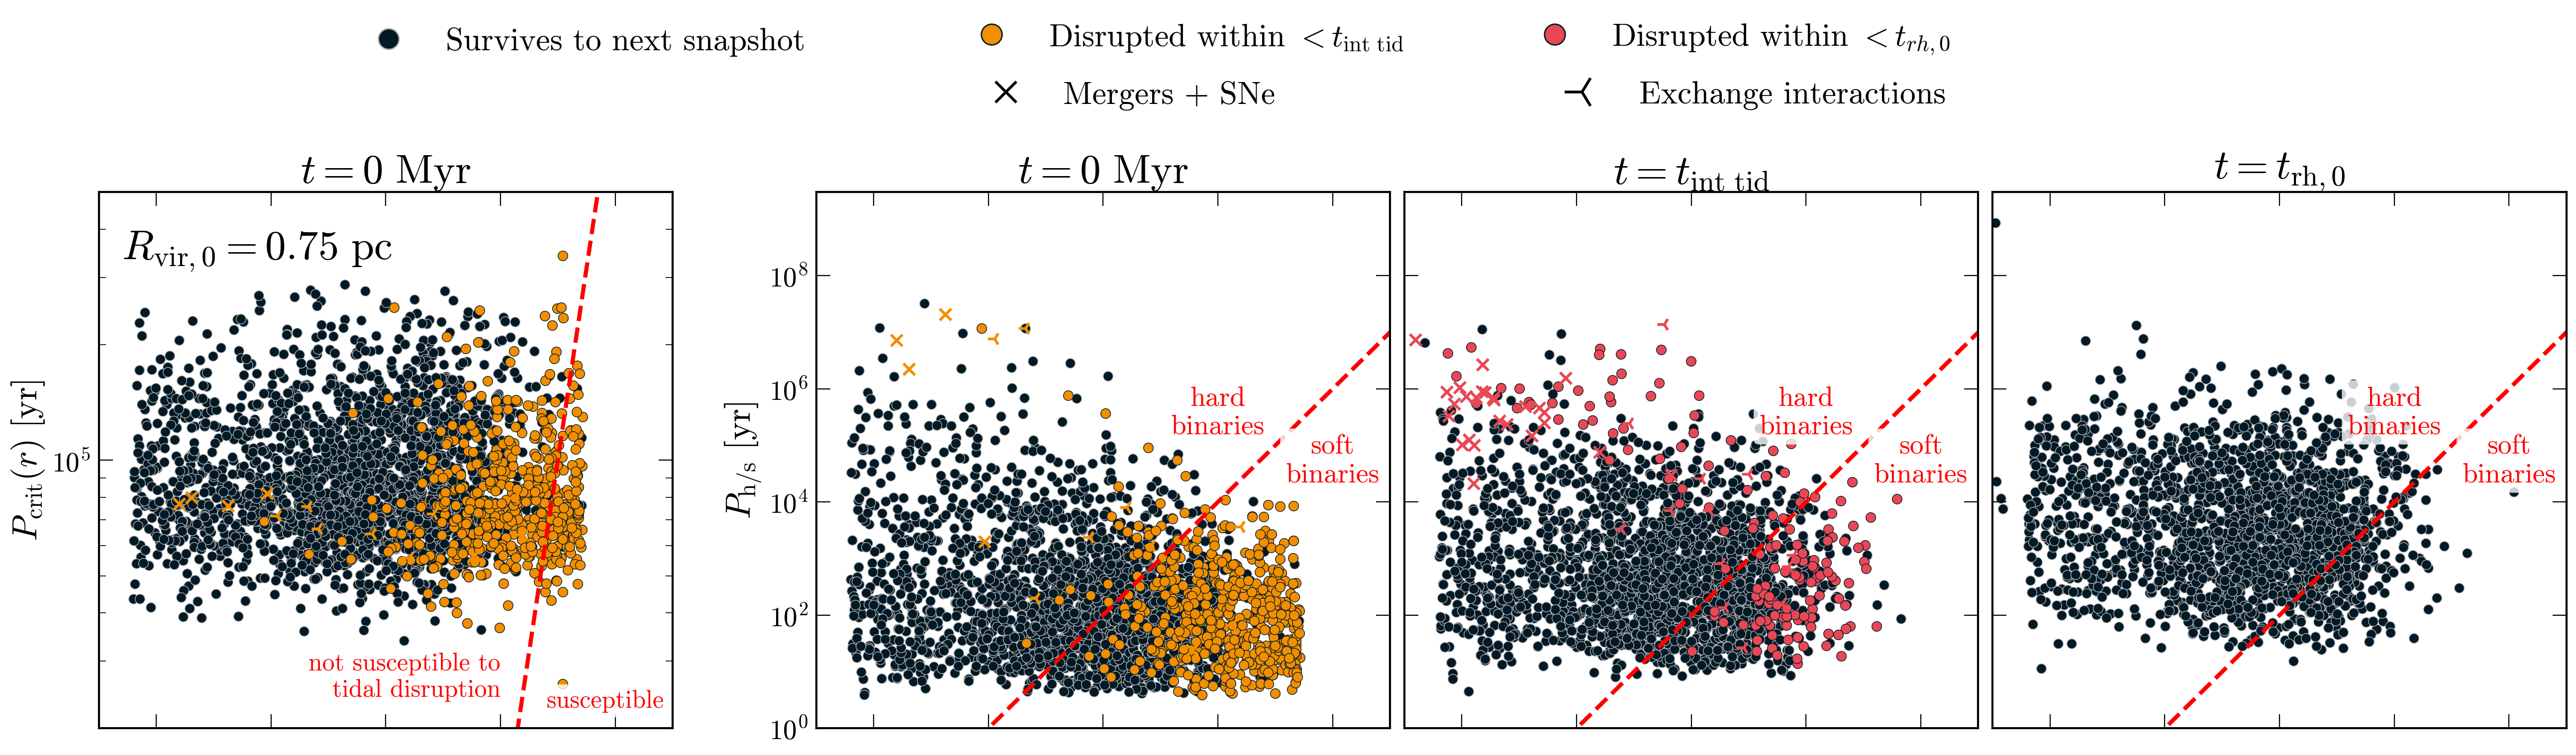

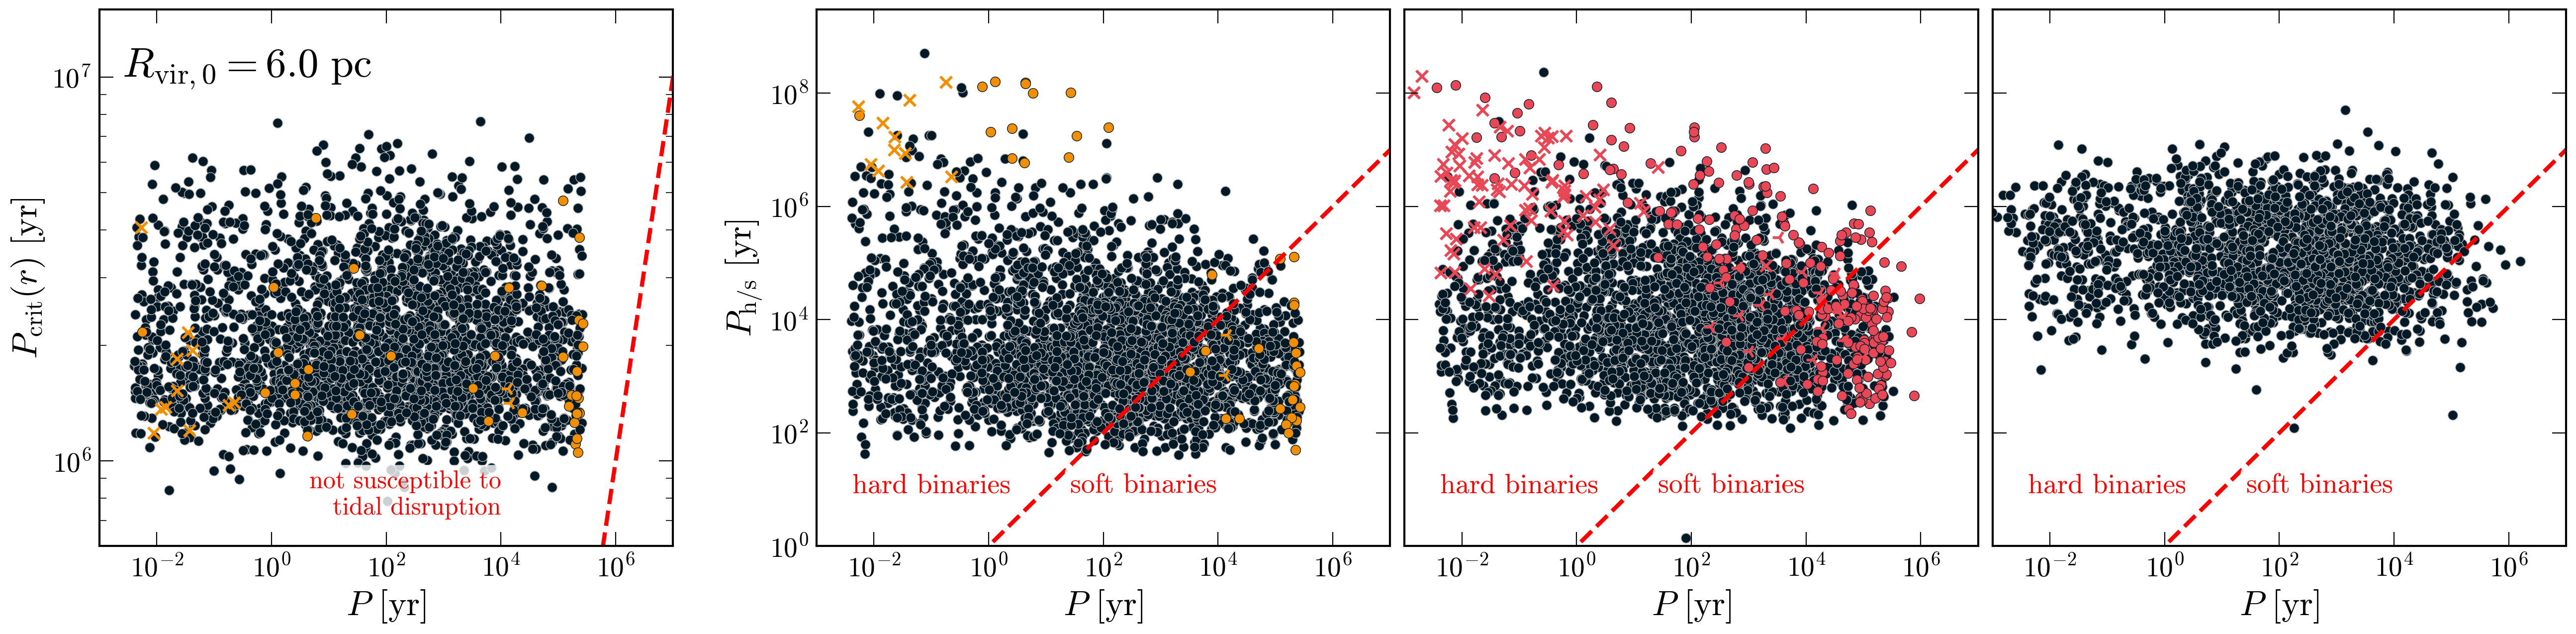

In [76]:
# testing.... 
fig, axs = make_ibe_plot(n=8, data_dict = figure_data_dict8_loaded, 
                    ylim0=[2e4,5e5], include_both_panel1_annotations=True,
                  include_titles=True, include_xlabels=False)

legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
              markerfacecolor="#031926", markeredgecolor='0.7', markersize=15,
              label='Survives to next snapshot'),
    Line2D([0],[0], marker='o', linestyle='None',
            markerfacecolor="#F18F01", markeredgecolor="#031926", markersize=15,
            label=r'Disrupted within $<t_{\rm int\ tid}$      '),
    Line2D([0],[0], marker='o', linestyle='None', markersize=15,
            markerfacecolor="#E84855", markeredgecolor="#031926", 
            label=r'Disrupted within $<t_{rh,0}$'),
    Line2D([0],[0], marker='x',linestyle='None', markeredgewidth=2,
                 markersize=15, markeredgecolor='k', label='Mergers + SNe                    '), 
    Line2D([0],[0], marker='3', linestyle='None',
                 markersize=25, markeredgecolor='k',  markeredgewidth=2,
            label='Exchange interactions')
]

leg_els0 = [legend_elements[0]]
leg_els1 = legend_elements[1:3]
leg_els2 = legend_elements[3:]

axs[0].legend(handles=leg_els0, loc='lower left',
                bbox_to_anchor=[0.4, 1.2], ncols=1,
                fontsize=23)

axs[2].legend(handles=leg_els1, 
              loc='lower left',
              bbox_to_anchor=[0.2,1.2], ncol=3,
              fontsize=23)
axs[3].legend(handles=leg_els2,
              loc='lower left',
              bbox_to_anchor=[-0.8, 1.1], ncols=2,
              fontsize=23)

plt.savefig("plots/individual_binaries_sim8_t_inttid.pdf", dpi=300, bbox_inches="tight")


fig, axs = make_ibe_plot(n=14, data_dict = figure_data_dict14_loaded,
                          ylim0=[6e5,(1.5*10**7)], include_both_panel1_annotations=False,
                            include_titles=False, include_xlabels=True)
plt.savefig("plots/individual_binaries_sim14_t_inttid.pdf", dpi=300, bbox_inches='tight')

# making the plots.

In [97]:
# make_ibe_plot(n=8, ylim0=[2e4,5e5],t_divide="1myr",
#                include_both_panel1_annotations=True, save=True)

In [98]:
# make_ibe_plot(n=8, ylim0=[2e4,5e5],t_divide="2tdyn0",
#                include_both_panel1_annotations=True, save=True)

In [ ]:
make_ibe_plot(n=8, ylim0=[2e4,5e5],t_divide=t_int_tides_list[0],
               include_both_panel1_annotations=True, save=True)

dividing time:  7
finding disruption times starting from t=0


 91%|█████████ | 10/11 [00:07<00:00,  1.28it/s]

In [ ]:
# make_ibe_plot(n=14, ylim0=[6e5,(1.5*10**7)],
#               include_both_panel1_annotations=False, save=True)

finding disruption times starting from t=0


100%|██████████| 20/20 [00:44<00:00,  2.24s/it]


tracing binary outcomes


100%|██████████| 2666/2666 [00:43<00:00, 61.24it/s] 


final count of stars that disappeared:  58
making panel 1
MAKING PANEL 2
finding disruption times starting from t=t_cutoff


...

tracing binary outcomes


100%|██████████| 2613/2613 [01:50<00:00, 23.73it/s]


final count of stars that disappeared:  305
making 3rd panel


/n/home02/amphillips/.conda/envs/petar_env/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


makign fourth panel


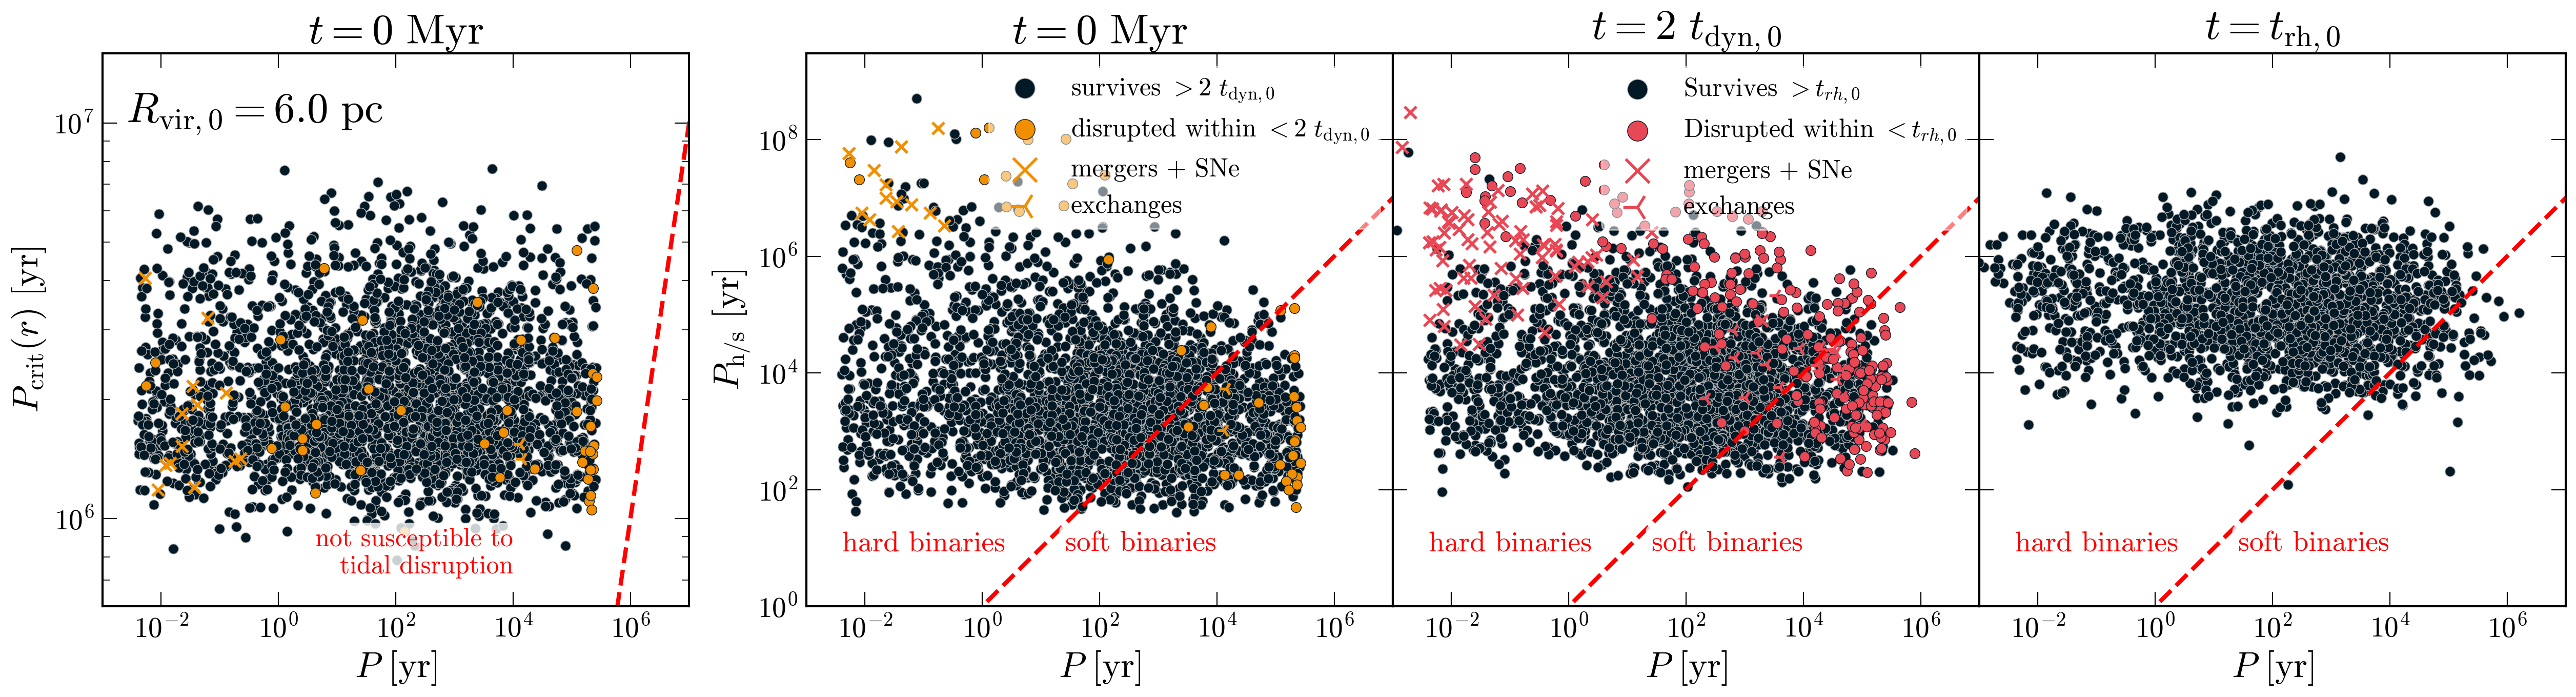

In [ ]:
# make_ibe_plot(n=14, ylim0=[6e5,(1.5*10**7)], t_divide="2tdyn0",
#               include_both_panel1_annotations=False, save=True)

dividing time:  14
finding disruption times starting from t=0


100%|██████████| 18/18 [00:15<00:00,  1.16it/s]


tracing binary outcomes


100%|██████████| 2666/2666 [00:08<00:00, 332.59it/s]


final count of stars that disappeared:  51
making panel 1
MAKING PANEL 2
finding disruption times starting from t=t_cutoff


...

tracing binary outcomes


100%|██████████| 2622/2622 [01:28<00:00, 29.73it/s] 


final count of stars that disappeared:  314
making 3rd panel


/n/home02/amphillips/.conda/envs/petar_env/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


makign fourth panel


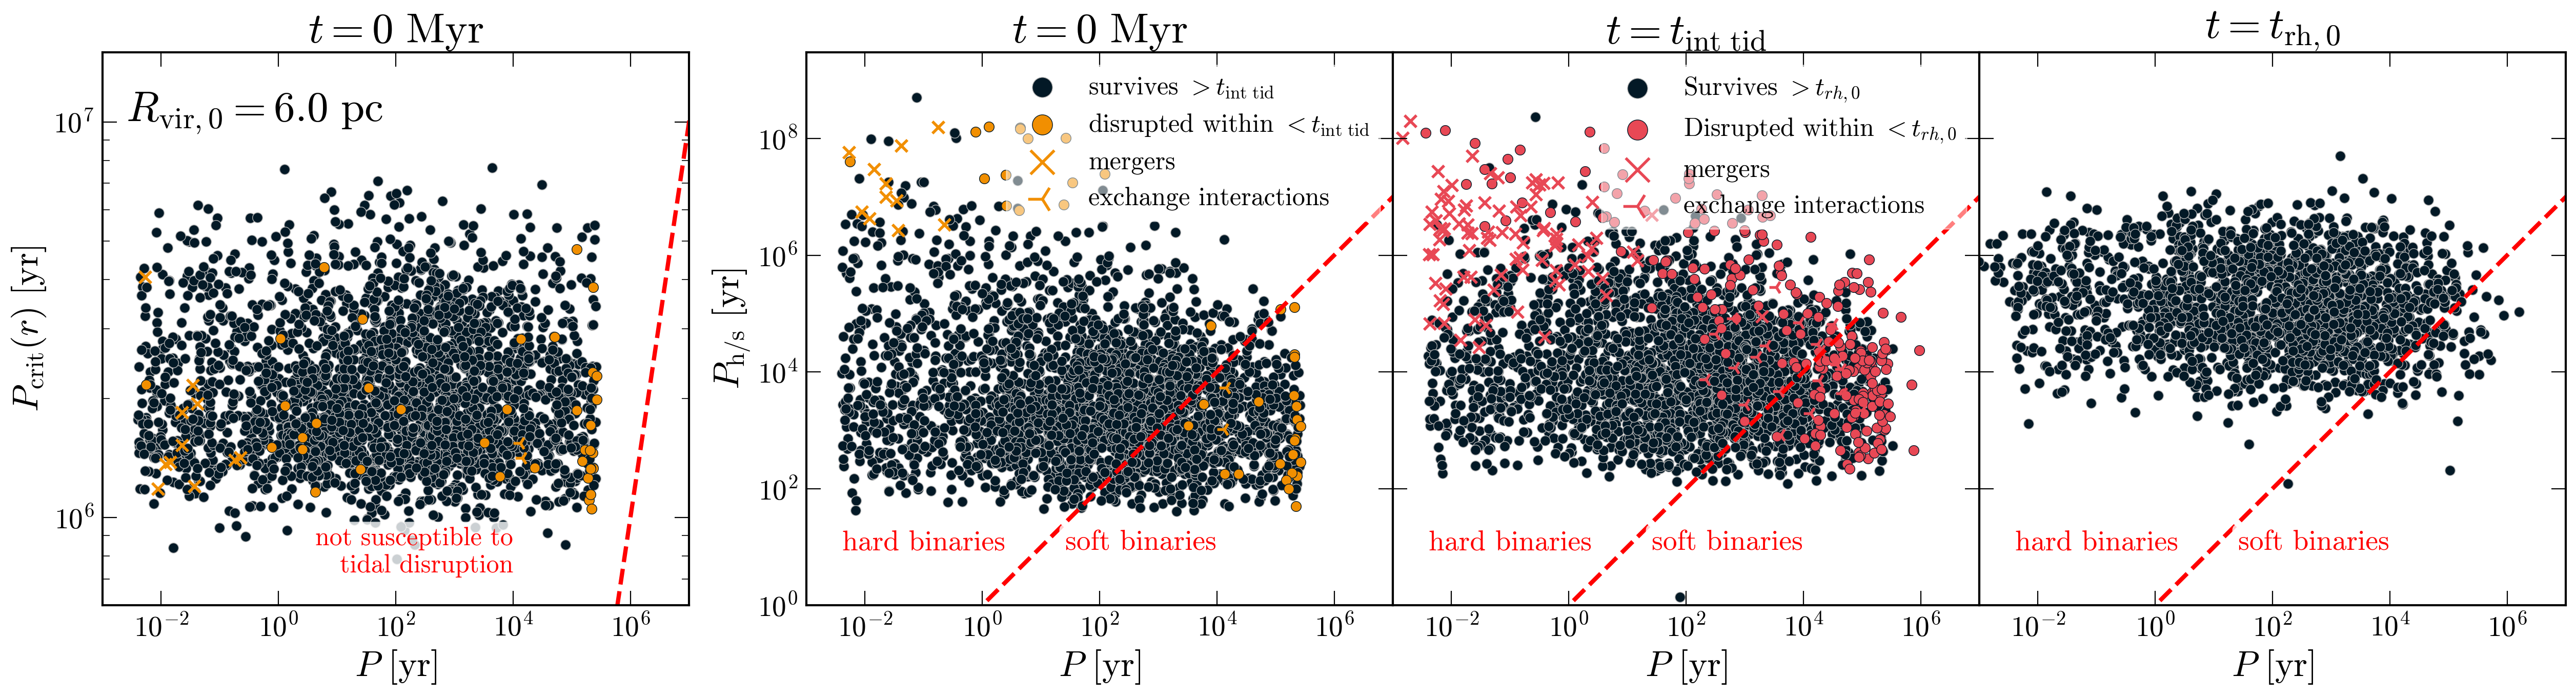

In [ ]:
make_ibe_plot(n=14, ylim0=[6e5,(1.5*10**7)], t_divide=t_int_tides_list[1],
              include_both_panel1_annotations=False, save=True)

# checking on "lucky" soft binaries that survive to t_rh0...

In [9]:
# load binaries at t_int_tides
### check their radii relative to cluster core, mass, period, eccentricity, Phs
n = 8

ahs_i, b_r_i, a_i, Mtot_i, rh_i, in_rtid_binary_i = paf.compute_ahs(paths[n], i=7, shell_width=0.5*u.pc)

binaries_i = petar.Binary(member_particle_type=petar.Particle, interrupt_mode='bse', external_mode='galpy')
binaries_i.loadtxt(paths[n]+"data.7.binary")
binaries_i = binaries_i[in_rtid_binary_i] # matches binary properties to ahs...i think haha

soft_flag_i = a_i >= ahs_i

# get binary IDs for survival matching
p1id_i, p2id_i = binaries_i.p1.id, binaries_i.p2.id
bid_i = np.array([np.sort([p1id, p2id]) for p1id, p2id in zip(p1id_i, p2id_i)] )
bid_i = np.array([str(a)+str(b) for a,b in bid_i]) # create unique binary IDs that are strings to compare to those at the final time. 


# load binaries at t_rh,0
### check their radii relative to cluster core, mass, period, eccentricity, Phs
ahs_f, b_r_f, a_f, Mtot_f, rh_f, in_rtid_binary_f = paf.compute_ahs(paths[n], i=int(t_rh0[n]), shell_width=0.5*u.pc)
binaries_f = petar.Binary(member_particle_type=petar.Particle, interrupt_mode='bse', external_mode='galpy')
binaries_f.loadtxt(paths[n]+"data.%i.binary"%t_rh0[n])
# to get rid of things that just escaped, only keep things still in the cluster at the final time...
# binaries_f = binaries_f[in_rtid_binary_f]

p1id_f, p2id_f = binaries_f.p1.id, binaries_f.p2.id
bid_f = np.array([np.sort([p1id, p2id]) for p1id, p2id in zip(p1id_f, p2id_f)] )
bid_f = np.array([str(a)+str(b) for a,b in bid_f]) # create unique binary IDs that are strings to compare to those at the final time. 

survives_flag = np.isin(bid_i, bid_f)
# make a "survives" flag for the binaries at t_int_tides
### check the demographic distributions for binaries_at_t_inttid[survives]


/n/home02/amphillips/.conda/envs/petar_env/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [10]:
# plotting functions

def make_hist(vals, ax, bins=20, rotation='horizontal', density=True):
    ax.hist(vals[survives_flag & soft_flag_i], linewidth=3, label='survives', histtype='step', density=density,
            orientation=rotation, bins=bins, color='k')
    ax.hist(vals[~survives_flag & soft_flag_i], linewidth=3, label='disrupted', histtype='step', density=density,
            orientation=rotation, bins=bins, color='r')

# making scatter plots instead?
def make_scatter(x, y, ax):
    ax.scatter(x[survives_flag & soft_flag_i], y[survives_flag & soft_flag_i], label='survives', c='k')
    ax.scatter(x[~survives_flag & soft_flag_i], y[~survives_flag & soft_flag_i], label='disrupted', c='r')


Text(0, 0.5, 'pdf')

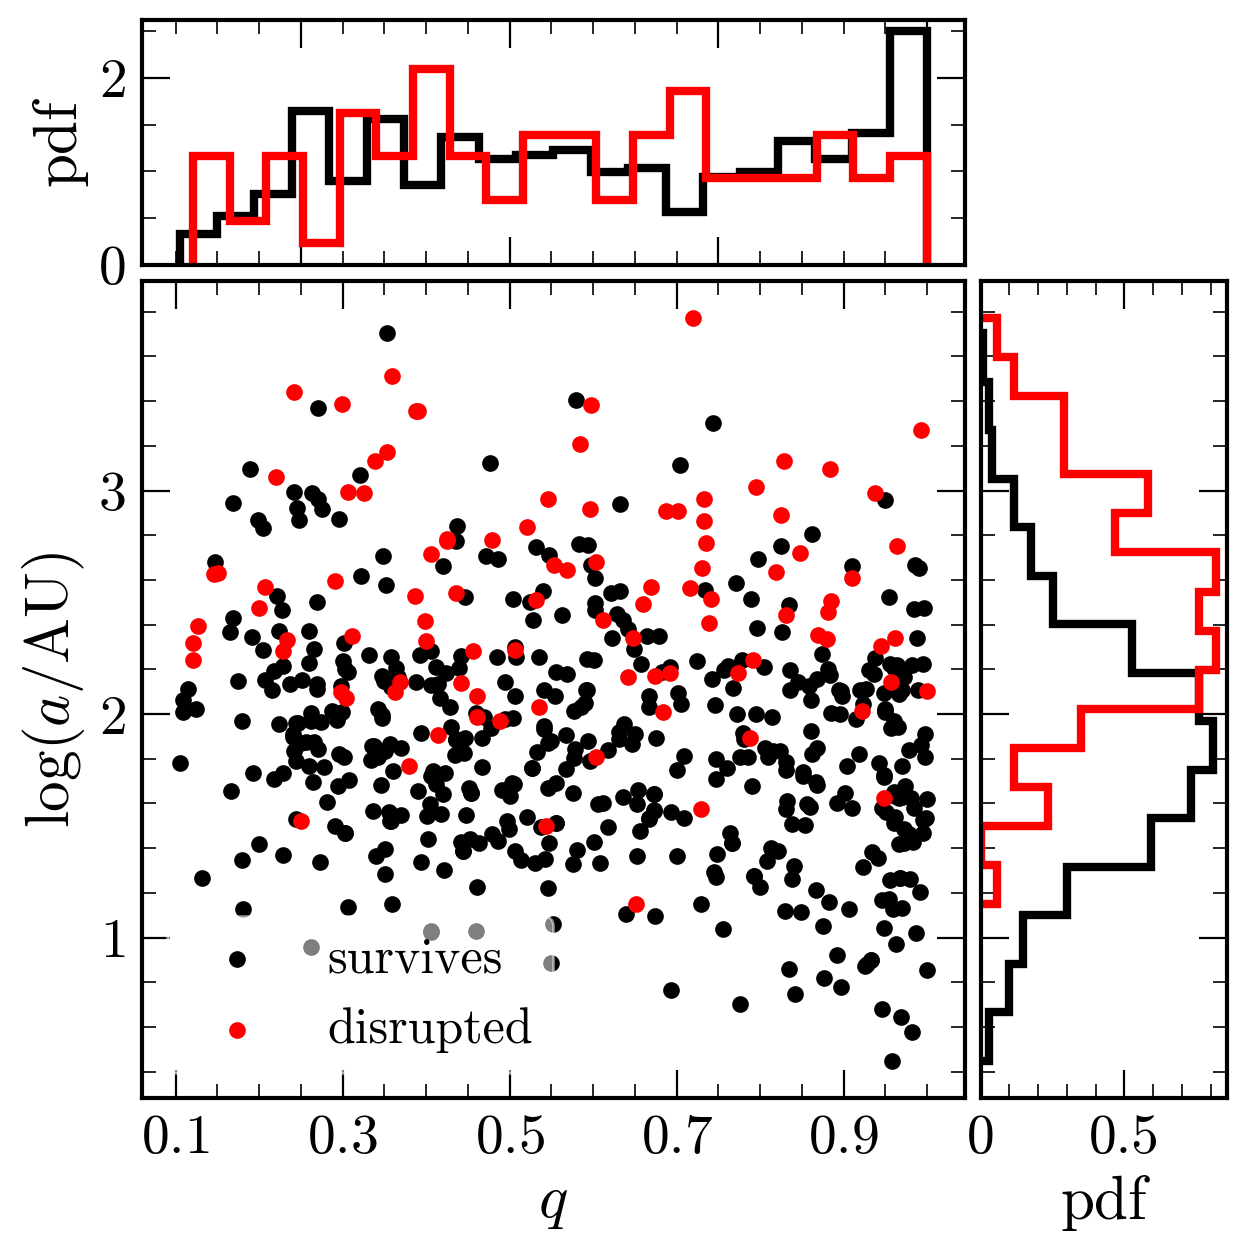

In [ ]:


### mass ratio
m1 = np.maximum(binaries_i.p1.mass, binaries_i.p2.mass)
m2 = np.minimum(binaries_i.p1.mass, binaries_i.p2.mass)
q = m2/m1




# x = np.log10(b_r_i.to(u.pc).value)
x = q 
# x = binaries_i.ecc
# x=np.log10(binaries_i.mass)
y = np.log10(a_i.to(u.au).value)



fig, axs = plt.subplots(2,2,width_ratios = [1, 0.3], height_ratios = [0.3,1])
plt.subplots_adjust(wspace=0.03, hspace=0.03)
axs[0,1].remove()

make_scatter(x,y,axs[1,0])
make_hist(x, axs[0,0], rotation='vertical')
make_hist(y, axs[1,1], rotation='horizontal', bins=15)

axs[1,1].set_yticklabels([])
axs[0,0].set_xticklabels([])

axs[1,0].set_xlabel(r'$q$')
axs[1,0].set_ylabel(r'$\log(a/\mathrm{AU})$')
axs[1,0].set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
axs[1,0].legend(loc='lower left', framealpha=0.5)

axs[1,1].set_xticks([0,0.5],['0','0.5'])
axs[1,1].set_xlabel('pdf')
axs[0,0].set_ylabel('pdf')

Text(0, 0.5, '$r\\ \\mathrm{pc})$')

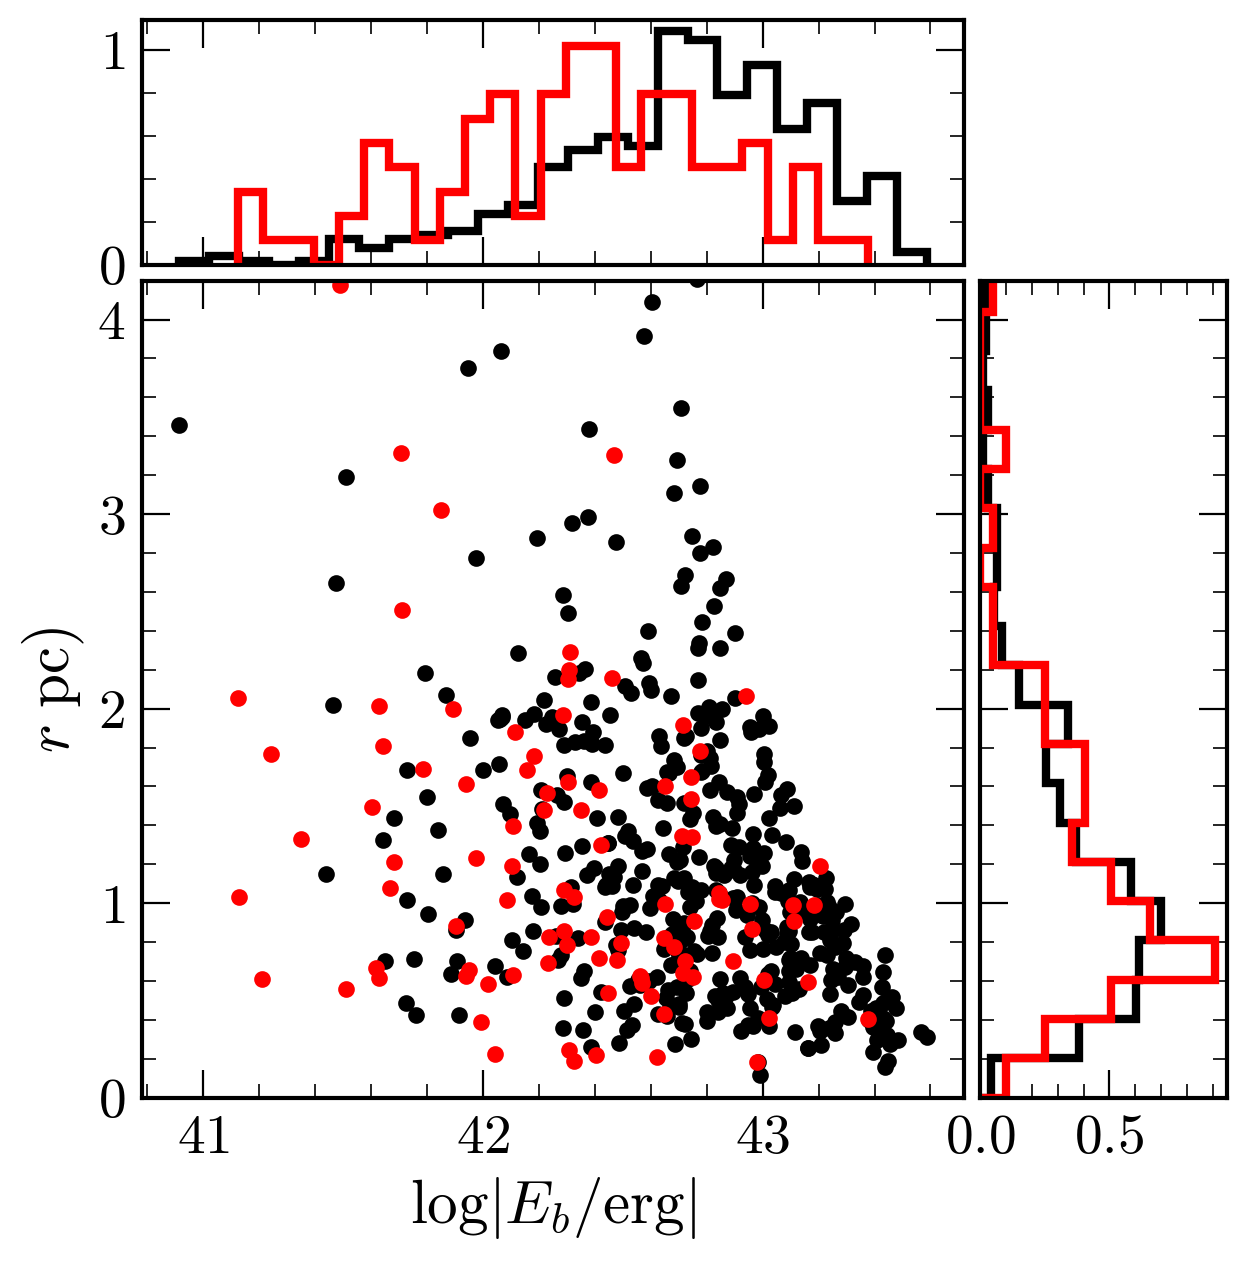

In [ ]:
def E_b(m1, m2, a, e):
    """
    calculate binding energy (*real*)
    **all of this is not necessary, binding energy = Gm1m2/2a**
    """

    Mtot = m1 + m2
    m1m2 = m1*m2

    r_peri = a*(1-e)
    vel_peri = np.sqrt(const.G * Mtot / a) * np.sqrt((1+e)/(1-e))

    r1 = (1-(m1/Mtot))*r_peri
    r2 = (m1/Mtot)*r_peri

    v1 = (1-(m1/Mtot))*vel_peri
    v2 = (m1/Mtot)*vel_peri

    V = -const.G * m1m2 / (r1+r2) 
    K = 0.5 * (m1*v1**2 + m2*v2**2)
    
    Eb = K+V

    return Eb


binding_energies_i = E_b(
    binaries_i.p1.mass*u.Msun,
    binaries_i.p2.mass * u.Msun,
    binaries_i.semi*u.pc,
    binaries_i.ecc
)

# np.abs(binding_energies_i.decompose())

# x = np.log10(b_r_i.to(u.pc).value)
# x = q # binaries_i.ecc
x = np.log10(np.abs(binding_energies_i.cgs.value))
# x=np.log10(binaries_i.mass)
# y = np.log10(a_i.to(u.au).value)
y = b_r_i.to(u.pc).value



fig, axs = plt.subplots(2,2,width_ratios = [1, 0.3], height_ratios = [0.3,1])
plt.subplots_adjust(wspace=0.03, hspace=0.03)
axs[0,1].remove()

make_scatter(x,y,axs[1,0])
make_hist(x, axs[0,0], rotation='vertical', bins=25)
make_hist(y, axs[1,1], rotation='horizontal', bins=np.linspace(0, 20, 100))
axs[1,0].set_ylim(0,4.2)
axs[1,1].set_ylim(0,4.2)
axs[1,1].set_yticklabels([])
axs[0,0].set_xticklabels([])
axs[1,0].set_xlabel(r'$\log|E_b/\mathrm{erg}|$')
axs[1,0].set_ylabel(r'$r\ \mathrm{pc})$')

# # axs[1,0].legend()

  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_1039691/3170573645.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  vel_peri = np.sqrt(const.G * Mtot / a) * np.sqrt((1+e)/(1-e))
/n/home02/amphillips/.conda/envs/petar_env/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/n/home02/amphillips/.conda/envs/petar_env/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in add
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
100%|██████████| 10/10 [00:00<00:00, 312.16it/s]


Text(0, 0.5, '$E_{b}\\ \\rm[erg]$')

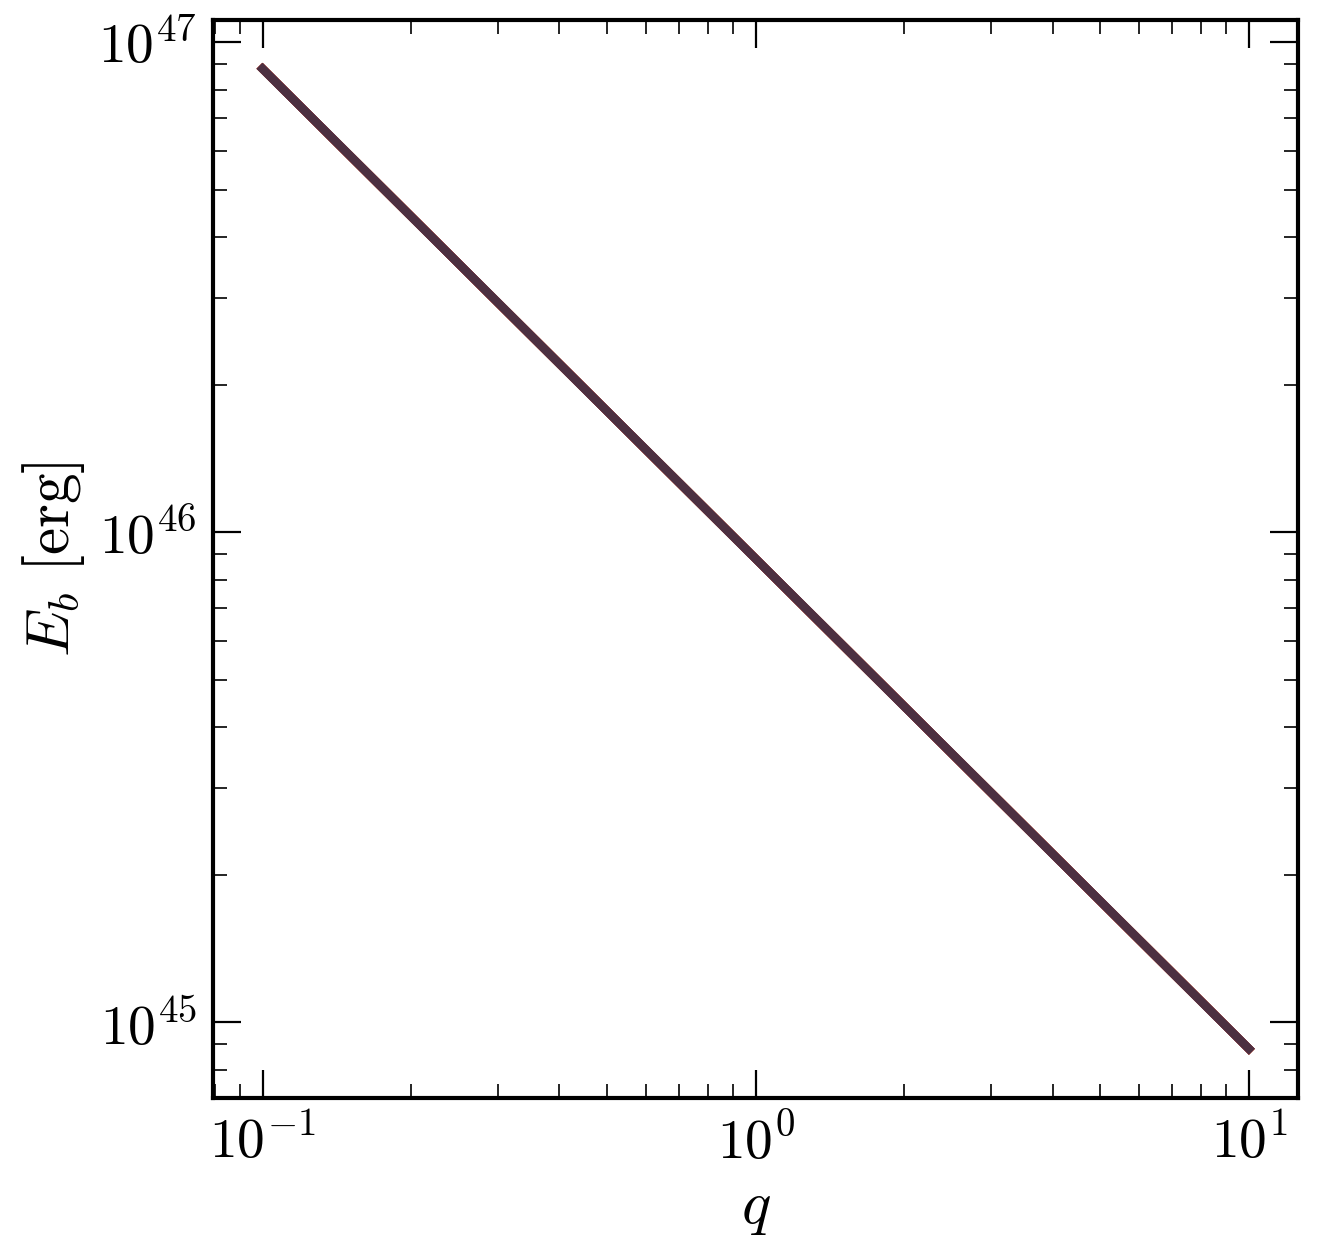

In [19]:
m1 = 1 * u.Msun
m2 = 1 * u.Msun
a = np.logspace(-1, 1, 100)*u.au
# m2_arr = np.logspace(-1, 1, 100)*u.Msun


evals = np.linspace(0,1,10)
fig, ax = plt.subplots()
c = time_cmap(np.linspace(0, 1, len(evals)))
cindex=0
for e in tqdm(evals):
    Eb_arr = E_b(m1, m2, a, e)
    ax.plot(a, np.abs(Eb_arr.cgs.value), color=c[cindex])
    cindex+=1

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$E_{b}\ \rm[erg]$')

# recasting axes in terms of binding energy.

In [ ]:
def get_hard_soft_info(path, i, shell_width=0.5*u.pc, interrupt='bse'):
    single_file = path+"data."+str(i)+".single"
    singles = petar.Particle(interrupt_mode=interrupt, external_mode="galpy")
    singles.loadtxt(single_file)#, skiprows=1)
    single_pos = singles.pos*u.pc
    single_vel = (singles.vel*(u.pc/u.Myr)).to(u.km/u.s)
    sx, sy, sz = single_pos.T
    sr = np.sqrt(sx**2 + sy**2 + sz**2)
    svx, svy, svz = single_vel.T
    sv = np.sqrt(svx**2 + svy**2 + svz**2)
    single_masses = singles.mass * u.Msun
    
    
    # binaries - load in core frame
    binary_file = path+"data."+str(i)+".binary"
    binaries = petar.Binary(member_particle_type=petar.Particle, G=petar.G_MSUN_PC_MYR, 
                            interrupt_mode=interrupt, external_mode='galpy')
    binaries.loadtxt(binary_file)#, skiprows=1)
    binary_pos = binaries.pos*u.pc
    binary_vel = (binaries.vel*(u.pc/u.Myr)).to(u.km/u.s)
    bx, by, bz = binary_pos.T
    br = np.sqrt(bx**2 + by**2 + bz**2)
    bvx, bvy, bvz = binary_vel.T
    bv = np.sqrt(bvx**2 + bvy**2 + bvz**2)
    binary_masses = binaries.mass * u.Msun
    
    all_r = np.concatenate([sr, br])
    all_v = np.concatenate([sv, bv])
    all_m = np.concatenate([single_masses, binary_masses])
    
    tidal = petar.external.Tidal()
    tidal.loadtxt(path+"data.tidal")
    rtid = tidal.rtid[i] * u.pc
    
    in_rtid_all = all_r<=rtid
    in_rtid_binary = br<=rtid
    
    r_in = all_r[in_rtid_all]
    v_in = all_v[in_rtid_all]
    m_in = all_m[in_rtid_all]
    
    def find_locally_averaged_m_sigma2(r, all_m, all_r, all_v, shell_width): # .2 pc
        outer = r+shell_width
        if r<shell_width:
            inner=0
            
        if r>=shell_width:
            inner = r-shell_width
        
        in_shell = (all_r>=inner) & (all_r<outer)
        r_in_shell = all_r[in_shell]
        m_in_shell = all_m[in_shell]
        Mtot_in_shell = np.sum(m_in_shell)
        n_in_shell = len(m_in_shell)
        Mavg = Mtot_in_shell / n_in_shell
        
        v_in_shell = all_v[in_shell]
        v2_in_shell = v_in_shell**2
        sigma2 = np.mean(v2_in_shell) - np.mean(v_in_shell)**2
        
        # print(Mavg.unit, sigma2.unit)
        return Mavg, sigma2
    

    
    # stats on the binaries
    m1s = binaries.p1.mass[in_rtid_binary] * u.Msun
    m2s = binaries.p2.mass[in_rtid_binary] * u.Msun
    brs = br[in_rtid_binary]
    semis = binaries.semi[in_rtid_binary] * u.pc
    Mtots = binaries.mass[in_rtid_binary] * u.Msun

    b_p1_ids, b_p2_ids = binaries.p1.id[in_rtid_binary], binaries.p2.id[in_rtid_binary]

    binary_IDs = np.array([np.sort([p1id, p2id]) for p1id, p2id in zip(b_p1_ids, b_p2_ids)])
    binary_IDs = np.array([str(a)+str(b) for a, b in binary_IDs])


    Eb_list = np.array([]) * u.erg
    E_local_list = np.array([]) * u.erg

    for k in range(len(brs)):
        br = brs[k]

        Mavg, sigma2 = find_locally_averaged_m_sigma2(br, all_m=m_in, all_r = r_in, all_v = v_in, shell_width=shell_width)
        E_local = 0.5 * Mavg * sigma2
        E_local_list = np.append(E_local_list, E_local)

        m1 = m1s[k]
        m2 = m2s[k]
        a = semis[k]
        
        Eb = const.G*m1*m2 / (2*a) # devastatingly simple :D
        Eb_list = np.append(Eb_list, Eb)

    return Eb_list, E_local_list, semis, Mtots, in_rtid_binary, binary_IDs

In [96]:
j = 1
n_list = [8,14]
n = n_list[j]
Ebs, Elocs, avals, mtots, in_rtid_binary, bids0 = get_hard_soft_info(paths[n], i=t_int_tides_list[j],
                                                                      shell_width=0.5*u.pc)

Ebs_f, Elocs_f, avals_f, mtots_f, in_rtid_binaryf, bidsf = get_hard_soft_info(paths[n],
                                                                               i=t_rh0[n], 
                                                                                shell_width=0.5*u.pc)

survives = np.isin(bids0, bidsf)

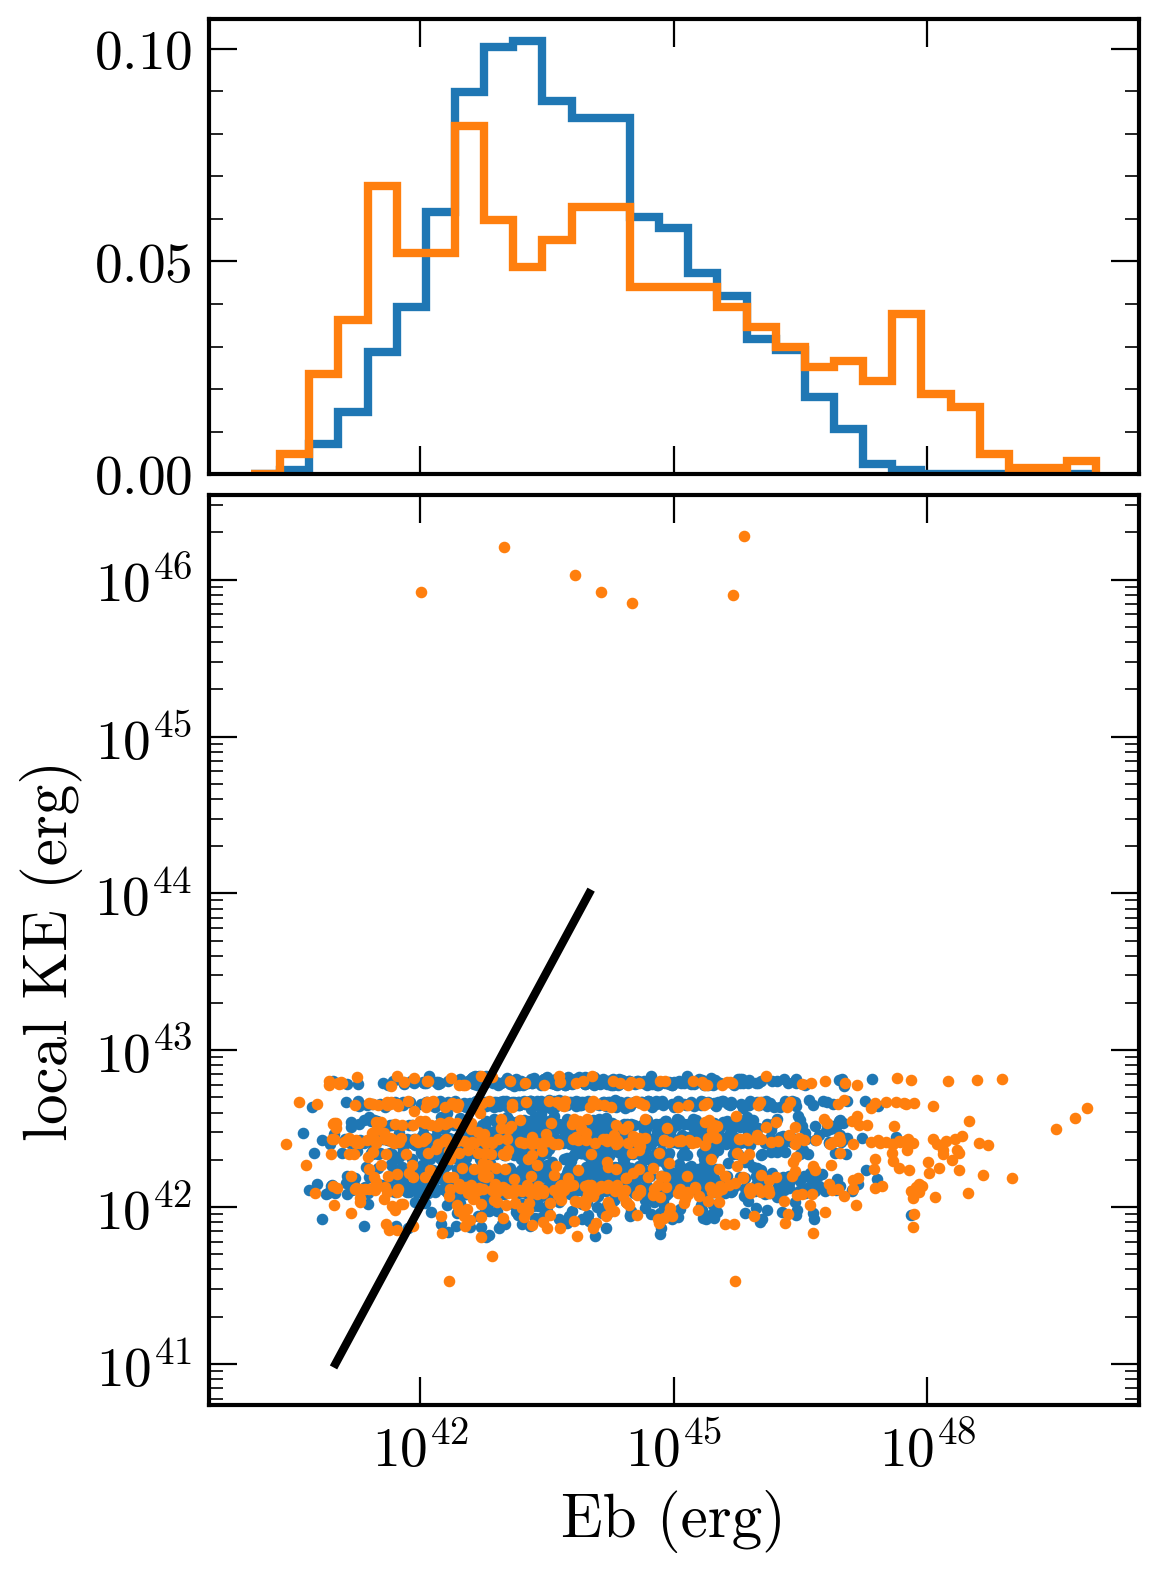

In [97]:
fig, axs = plt.subplots(2,1,height_ratios=[0.5, 1], sharex=True, figsize=[6,9])
plt.subplots_adjust(wspace=0.03, hspace=0.03)
axs[1].scatter(Ebs.to(u.erg)[survives], Elocs.to(u.erg)[survives], s=10)
axs[1].scatter(Ebs.to(u.erg)[~survives], Elocs.to(u.erg)[~survives], s=10)#, zorder=0)
# ax1scatter(Ebs_f.to(u.erg), Elocs_f.to(u.erg), s=10)
axs[1].set_yscale('log')
axs[1].set_xscale('log')

# ax.set_ylim(4.3e43, 4.7e43)


r = [1e41, 1e44]

axs[1].plot(r,r, c='k')

axs[1].set_xlabel("Eb (erg)")
axs[1].set_ylabel("local KE (erg)")

axs[0].hist(Ebs.to(u.erg)[survives].to(u.erg).value, bins=np.logspace(40, 50, 30),
            weights = np.zeros_like(Ebs[survives].value)+1/Ebs[survives].size,
            histtype='step', linewidth=3);#, Elocs.to(u.erg)[survives], s=10)
axs[0].hist(Ebs.to(u.erg)[~survives].to(u.erg).value, bins=np.logspace(40, 50, 30),
            weights = np.zeros_like(Ebs[~survives].value)+1/Ebs[~survives].size,
            histtype='step', linewidth=3);#, Elocs.to(u.erg)[~survives], s=10)#, zorder=0)

In [ ]:
«